--- Classification Results ---
Accuracy with Original (13 Features): 100.00%
Accuracy with PCA (2 Components): 100.00%
Accuracy with LDA (2 Components): 100.00%


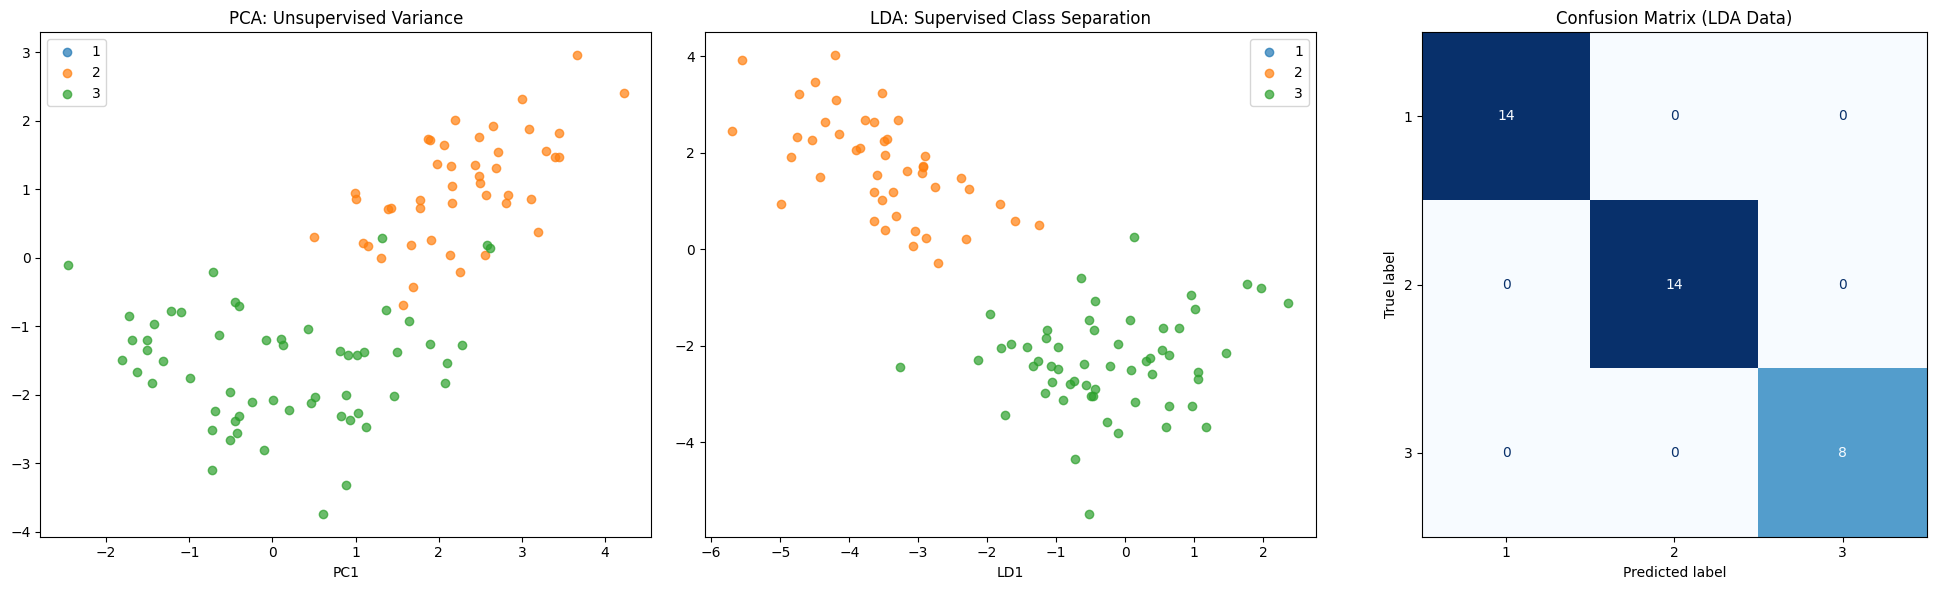

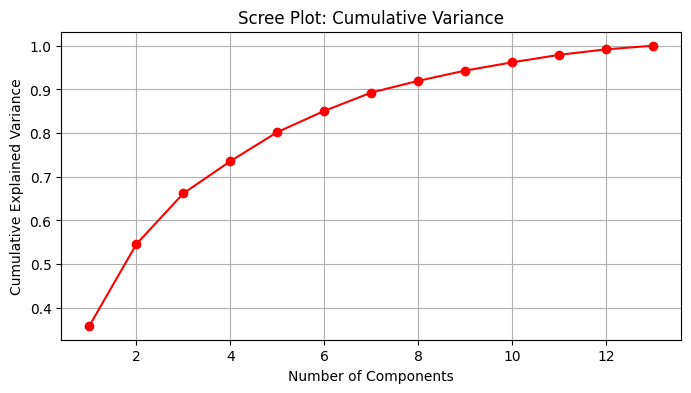

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
wine_df = pd.read_csv(os.path.join(path, 'Wine.csv'))
X = wine_df.iloc[:, :-1].values
y = wine_df.iloc[:, -1].values
target_names = np.unique(y).astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)
def evaluate_model(train_features, test_features, title):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(train_features, y_train)
    preds = clf.predict(test_features)
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy with {title}: {acc*100:.2f}%")
    return clf, preds
print("--- Classification Results ---")
model_orig, _ = evaluate_model(X_train_std, X_test_std, "Original (13 Features)")
model_pca, _  = evaluate_model(X_train_pca, X_test_pca, "PCA (2 Components)")
model_lda, preds_lda = evaluate_model(X_train_lda, X_test_lda, "LDA (2 Components)")
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
for i, name in enumerate(target_names):
    ax[0].scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], label=name, alpha=0.7)
ax[0].set_title("PCA: Unsupervised Variance")
ax[0].set_xlabel("PC1")
ax[0].legend()
for i, name in enumerate(target_names):
    ax[1].scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=name, alpha=0.7)
ax[1].set_title("LDA: Supervised Class Separation")
ax[1].set_xlabel("LD1")
ax[1].legend()
cm = confusion_matrix(y_test, preds_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax[2], cmap='Blues', colorbar=False)
ax[2].set_title("Confusion Matrix (LDA Data)")

plt.tight_layout()
plt.show()
pca_full = PCA().fit(X_train_std)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), 'ro-')
plt.title("Scree Plot: Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [2]:
import os

# The 'path' variable was set in a previous cell
print(os.listdir(path))

['Wine.csv']


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abrahamanderson/wine-data")

print("Path to dataset files:", path)

100%|██████████| 4.42k/4.42k [00:00<00:00, 5.71MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abrahamanderson/wine-data/versions/1
